# 02 - Expert Demonstration Collection (M2)

**Group members:** _add names here_

We roll out each deterministic expert and record (observation, action) pairs. Actions are the Gaussian-policy mean (`deterministic=True`), which reduces label noise. Produced by `collect_demos.py`.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
OUT, MODELS, LOGS = ROOT/'outputs', ROOT/'models', ROOT/'logs'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('missing figure:', name)
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok')

setup ok


## Dataset statistics and quality gate

In [2]:
from src import collect
rows = []
for key in ['Walker2d-v4', 'Ant-v4']:
    d = collect.load(ROOT/'data'/'demonstrations'/key)
    r = d['episode_returns']; thr = (2/3)*r.mean()
    rows.append(dict(dataset=key, episodes=len(r),
        transitions=len(d['observations']),
        mean_return=round(float(r.mean()),1), mean_len=round(float(d['episode_lengths'].mean()),1),
        pct_above_2_3=round(100*float((r>thr).mean()),1)))
pd.DataFrame(rows)

,dataset,episodes,transitions,mean_return,mean_len,pct_above_2_3
0,Walker2d-v4,100,97270,6043.6,972.7,97.0
1,Ant-v4,100,96092,6179.6,960.9,90.0


All datasets have >= 50 complete episodes (we collected 100), are stored as NumPy arrays, and pass the quality gate (>= 90% of episodes above two thirds of the mean).

## Exploratory data analysis (spec 5.3 + trajectory-length histogram)

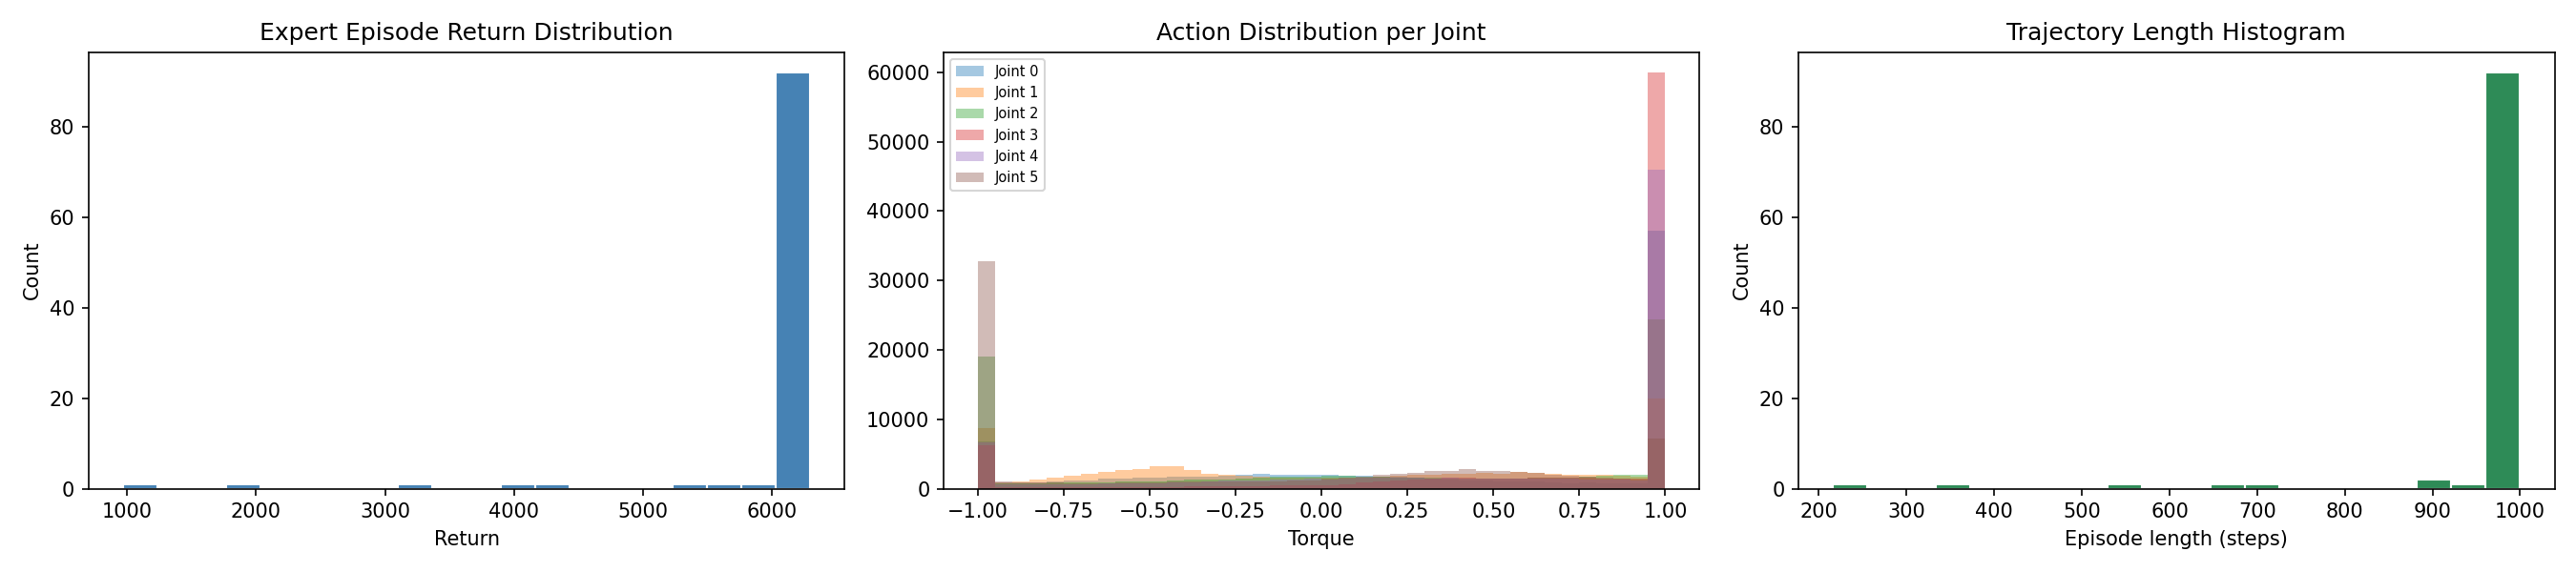

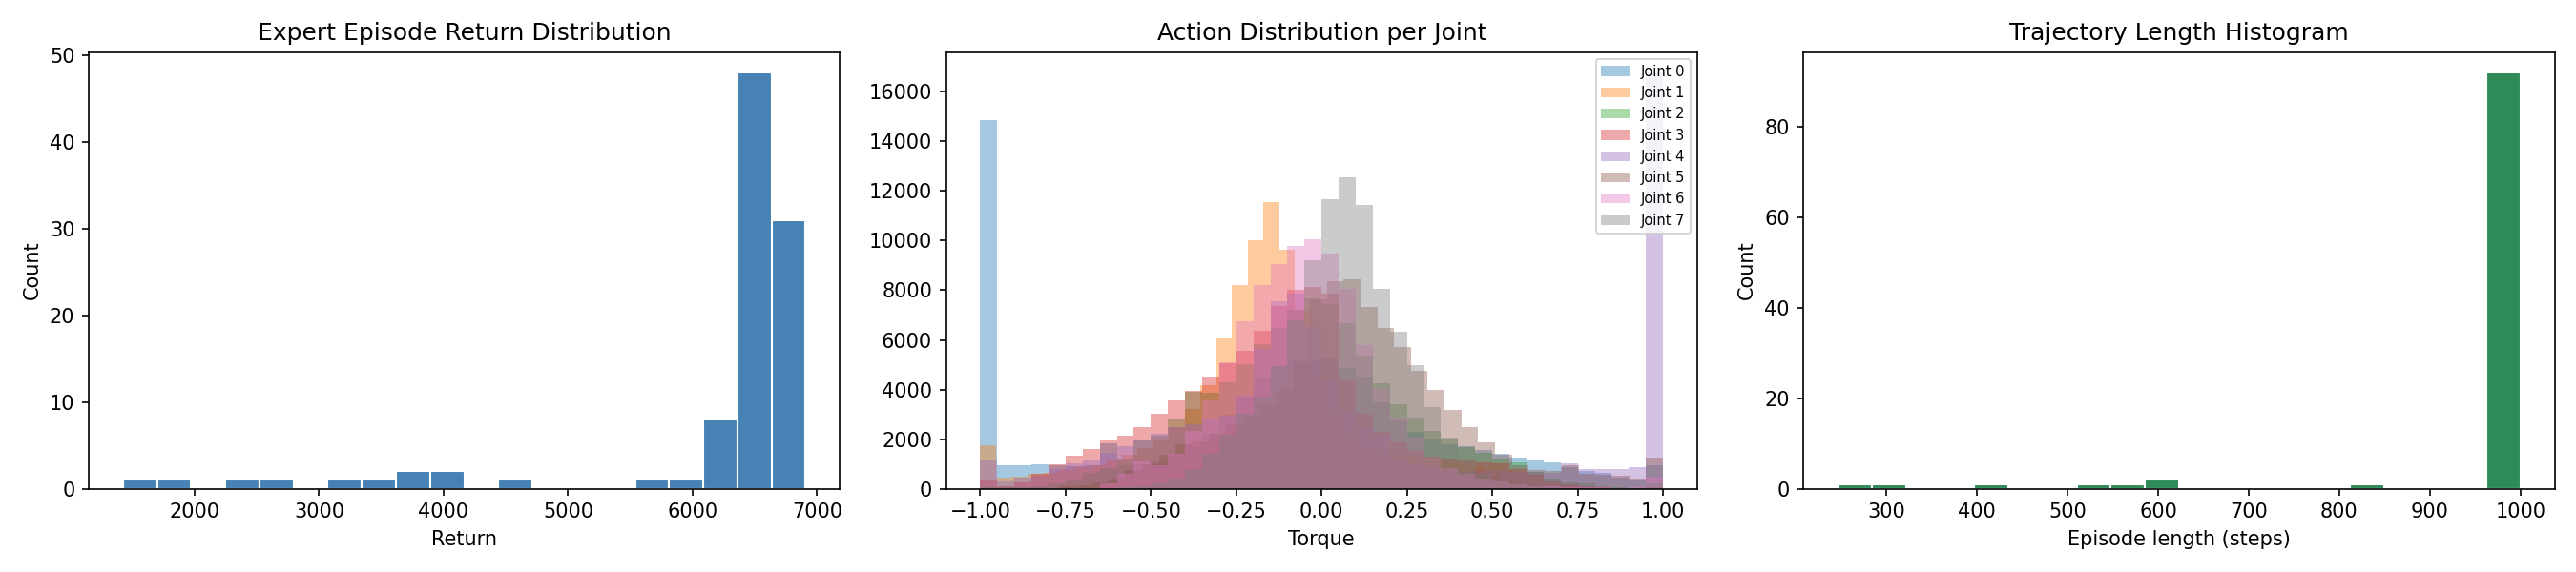

In [3]:
show('dataset_analysis_Walker2d-v4.png')
show('dataset_analysis_Ant-v4.png')

The return distributions are tight and high, per-joint action histograms show the experts use the full torque range (Walker2d in particular is near-bang-bang, `|a|` mean ~0.7), and the trajectory lengths sit near the 1000-step cap, so the experts rarely fall. Near-saturated actions make the stronger experts harder to clone (see notebook 03).